In [25]:
from loot import JavaRandom, get_loot_items, shuffle_and_split
from extract import get_chest_loot_table
from visualize import  visualize
# BT: 1,3
# DT: 3,4

In [26]:
def get_lcg_feature_seed(world_seed, block_x, block_z, index, step, calls=0):
    block_x &= 0xFFFFFFF0
    block_z &= 0xFFFFFFF0
    rng = JavaRandom(world_seed)
    
    a = (rng.next_long_() | 1)
    b = (rng.next_long_() | 1)
    
    dec_seed = (block_x * a + block_z * b ^ world_seed) & 0xFFFFFFFFFFFF
    feature_seed = (dec_seed + index + (10000 * step)) & 0xFFFFFFFFFFFFFFFF
    res = JavaRandom(feature_seed)
    for _ in range(calls): res.next_long_()
    return res.next_long_()

In [27]:
#loot_table_seed = 8367084861124633800
#x = 1113
#z = 665

#loot_table_seed = 1165133805057054727
x = 1865
z = 1481


#loot_table_seed = 2409643562167667466
#x = 2185
#z = 3561

loot_table_seed = get_lcg_feature_seed(777, x, z, 1, 3) # BT
table = 'buried_treasure'

In [28]:
x = 1312
z = 5952

x,z = 9296, 9248
loot_table_seed = get_lcg_feature_seed(777, x, z, 3, 4, calls=0) # DT

table = 'desert_pyramid'

In [29]:
rng = JavaRandom(loot_table_seed)
feature_seed = rng.seed
stacks = get_loot_items(get_chest_loot_table(table), rng)
loot_item_counts = {}
for item,qty in stacks:
    if item:
        if item not in loot_item_counts: loot_item_counts[item] = 0
        loot_item_counts[item] += qty

loot = shuffle_and_split(stacks, rng, 27)
print(loot_item_counts)

{'minecraft:golden_apple': 1, 'minecraft:spider_eye': 3, 'minecraft:rotten_flesh': 3, 'minecraft:sand': 7, 'minecraft:bone': 6, 'minecraft:string': 6}


In [30]:
from loot import shuffle
i = list(range(27))
r = JavaRandom(0)
r.seed = 239681203944956
shuffle(r, i)
print(i)

[25, 24, 2, 1, 17, 19, 0, 26, 23, 16, 5, 9, 21, 12, 11, 15, 22, 18, 14, 13, 10, 6, 20, 7, 3, 8, 4]


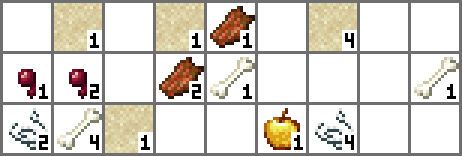

In [31]:
visualize(loot, scale=3)

In [32]:
#print(c)
#from loot import reverse_pool, reverse_rng_calls
#reverse_pool(2, get_chest_loot_table(table)['pools'][0]['entries'], c)
#reverse_rng_calls(get_chest_loot_table(table), c)

In [ ]:
def loottable_c(table):
    lookup = {'minecraft:empty':0}
    table = get_chest_loot_table(table)
    assert table['type'] == 'minecraft:chest'
    pools = table['pools']
    output = [len(pools)] #     #pools < rmin rmax #entries [ name weight qmin qmax ench ] >
    for pool in pools:
        rolls = pool['rolls']
        if type(rolls) is int:
            output.extend([rolls, rolls])
        elif type(rolls) is dict:
            rmin = rolls['min']
            rmax = rolls['max']
            assert rolls['type'] == 'minecraft:uniform'
            assert int(rmin) == rmin and int(rmax) == rmax
            output.extend([int(rmin), int(rmax)])
        else:
            raise ValueError
        entries = pool['entries']
        output.append(len(entries))
        for entry in entries:
            name = 'minecraft:empty' if entry['type'] == 'minecraft:empty' else entry['name']
            if name not in lookup: lookup[name] = len(lookup)
            output.append(lookup[name])
            output.append(entry.get('weight', 1))
            if 'functions' in entry:
                assert len(entry['functions']) == 1
                if entry['functions'][0]['function'] == 'minecraft:enchant_randomly':
                    output.extend([1, 1, 1])
                elif entry['functions'][0]['function'] == 'minecraft:set_count':
                    assert entry['functions'][0]['count']['type'] == 'minecraft:uniform'
                    qmin = entry['functions'][0]['count']['min']
                    qmax = entry['functions'][0]['count']['max']
                    assert int(qmin) == qmin and int(qmax) == qmax
                    output.extend([int(qmin), int(qmax), 0])
                else:
                    raise ValueError
            else:
                output.extend([1, 1, 0])
    return output, lookup

shuffle_order = 0
for i in range(27):
    shuffle_order |= ((loot[i] is not None) << i)
print(f"uint32_t shuffle_order = 0b{bin(shuffle_order)[2:].zfill(27)};")
loottable,lookup = loottable_c(table)
print(f"int64_t seed = {feature_seed};")
print(f"uint8_t table[{len(loottable)}] = {'{'}{str(loottable)[1:-1]}{'}'};")
targ = [0]*len(lookup)
for item,qty in loot_item_counts.items(): targ[lookup[item]] = qty
print(f"uint8_t target[{len(targ)}] = {'{'}{str(targ)[1:-1]}{'}'};")
print(f"int distinct_items = {len(lookup)};")

uint64_t shuffle_order = 0b001100111100011011001011010;
int64_t seed = 31254551618479;
uint8_t table[107] = {2, 2, 4, 15, 1, 5, 1, 3, 0, 2, 15, 1, 5, 0, 3, 15, 2, 7, 0, 4, 15, 1, 3, 0, 5, 25, 4, 6, 0, 6, 25, 1, 3, 0, 7, 25, 3, 7, 0, 8, 20, 1, 1, 0, 9, 15, 1, 1, 0, 10, 10, 1, 1, 0, 11, 5, 1, 1, 0, 12, 20, 1, 1, 1, 13, 20, 1, 1, 0, 14, 2, 1, 1, 0, 0, 15, 1, 1, 0, 4, 4, 5, 5, 10, 1, 8, 0, 15, 10, 1, 8, 0, 7, 10, 1, 8, 0, 16, 10, 1, 8, 0, 17, 10, 1, 8, 0};
uint8_t target[18] = {0, 0, 0, 0, 0, 6, 3, 3, 0, 0, 0, 0, 0, 1, 0, 0, 6, 7};
int distinct_items = 18;


In [34]:
def desert_pyramid_can_gen(wseed,cx,cz):
    spacing=32
    separation=8
    salt=14357617
    rx,rz=cx//spacing,cz//spacing
    r=JavaRandom(wseed+rx*341873128712+rz*132897987541+salt)
    return r.nextInt(spacing-separation)==(cx%spacing) and r.nextInt(spacing-separation)==(cz%spacing)
def treasure_can_gen(wseed,cx,cz):
    salt=10387320
    r=JavaRandom(wseed+cx*341873128712+cz*132897987541+salt)
    return r.nextFloat() < 0.01

######### From WorldGenRandom.class #########
def setBaseChunkSeed(integer1, integer2):
    long4 = integer1 * 341873128712 + integer2 * 132897987541
    return long4

def setDecorationSeed(long1, integer2, integer3):#population
    r=JavaRandom(long1)
    long6 = r.nextLong() | 0x1
    long8 = r.nextLong() | 0x1
    long10 = integer2 * long6 + integer3 * long8 ^ long1
    return long10&((1<<48)-1)

def setFeatureSeed(long1, integer2, integer3):#decoration
    long6 = long1 + integer2 + (10000 * integer3)
    return long6

def setLargeFeatureSeed(long1, integer2, integer3):
    r=JavaRandom(long1)
    long6 = r.nextLong()
    long8 = r.nextLong()
    long10 = integer2 * long6 ^ integer3 * long8 ^ long1
    return long10

def setLargeFeatureWithSalt(long1, integer2, integer3, integer4):
    long7 = integer2 * 341873128712 + integer3 * 132897987541 + long1 + integer4
    return long7
######### End #########


def btloot(wseed,cx,cz):
    index,step=salts['bt']
    loot_seed=JavaRandom(setFeatureSeed(setDecorationSeed(wseed,cx<<4,cz<<4),index,step)).nextLong()
    return loot(loot_seed,bt)

def dtlootseed(wseed,cx,cz,i):
    index,step=salts['des']
    r=JavaRandom(setFeatureSeed(setDecorationSeed(wseed,cx<<4,cz<<4),index,step))
    for j in range(i):r.nextLong()
    return r.nextLong()

In [35]:
enchantments = [
    "protection", "fire_protection", "feather_falling", "blast_protection",
    "projectile_protection", "respiration", "aqua_affinity", "thorns",
    "depth_strider", "frost_walker", "binding_curse", "sharpness", "smite",
    "bane_of_arthropods", "knockback", "fire_aspect", "looting", "sweeping",
    "efficiency", "silk_touch", "unbreaking", "fortune", "power", "punch",
    "flame", "infinity", "luck_of_the_sea", "lure", "loyalty", "impaling",
    "riptide", "channeling", "multishot", "quick_charge", "piercing",
    "mending", "vanishing_curse"
]
enchant_data = {
    "protection": 4, "fire_protection": 4, "feather_falling": 4,
    "blast_protection": 4, "projectile_protection": 4, "respiration": 3,
    "aqua_affinity": 1, "thorns": 3, "depth_strider": 3, "frost_walker": 2,
    "binding_curse": 1, "sharpness": 5, "smite": 5, "bane_of_arthropods": 5,
    "knockback": 2, "fire_aspect": 2, "looting": 3, "sweeping": 3,
    "efficiency": 5, "silk_touch": 1, "unbreaking": 3, "fortune": 3,
    "power": 5, "punch": 2, "flame": 1, "infinity": 1, "luck_of_the_sea": 3,
    "lure": 3, "loyalty": 3, "impaling": 5, "riptide": 3, "channeling": 1,
    "multishot": 1, "quick_charge": 3, "piercing": 4, "mending": 1,
    "vanishing_curse": 1
}
enc_pack = 0
for idx,ench in enumerate(enchantments):
    enc_pack |= ((enchant_data[ench]!=1)<<idx)
bin(enc_pack)

'0b11001111100111101111111101110111111'